# Master in Applied Artificial Intelligence

## Course: *Computer Vision for Images and Video*

### **3.2 Google Colab** - Spatial Domain Image Enhancement Algorithms

---

**Institution:** Tecnológico de Monterrey

**Instructors:** Gilberto Ochoa Ruiz, Daniel Flores Araiza, Ma. del Refugio Meléndez Alfaro

**Authors (Team 38):** 

|  FULL NAME                      |     STUDENT ID    | 
| :--------------------------:    |:-----------------:|
| Alejandro Díaz Villagómez       |  A01276769        | 
| Carlos Rodrigo Sánchez Sierra   |  A01424454        | 
| Emiliano Saucedo Arriola        |  A01659258        | 

**Date:** September 28th, 2025

---

# 3. Image Convolution

## Table of Contents
1. [Libraries](#libraries)
2. [Simple Example](#simple)
3. [PyTorch Convolution](#pytorch)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

## Simple Convolution <a class="anchor" id="simple" ></a>

### Definition

- __I__: Image to convolve.
- __H__: filter matrix to convolve the image with.
- __J__: Result of the convolution.

The following graphics shows exemplary the mathematical operations of the convolution. The filter matrix __H__ is shifted over the input image __I__. The values 'under' the filter matrix are multiplicated with the corresponding values in __H__, summed up and writen to the result __J__. The target position is usually the position under the center of __H__.

<img src="data/convolution.png" width="70%">

In order to implement the convolution with a block filter, we need two methods. The first one will create the block filter matrix __H__ depending on the filter width/height __n__. 

A block filter holds the value $\dfrac{1}{n\cdot n}$ at each position:

In [2]:
def block_filter(n):
    H = np.ones((n, n)) / (n * n) # each element in H has the value 1/(n*n)
    return H

We will test the method by creating a filter with ``n = 5``:

In [3]:
H = block_filter(5)
print(H)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


Next, we define the actual convolution operation. To prevent invalid indices at the border of the image, we introduce the padding __p__.

In [4]:
def apply_filter(I, H):
    h, w = I.shape                         # image dimensions (height, width)
    n = H.shape[0]                         # filter size
    p = n // 2                             # padding size
    J = np.zeros_like(I)                   # output image, initialized with zeros
    
    for x in range(p, h-p):
        for y in range(p, w-p):
            J[x, y] = np.sum(I[x-p:x+n-p, y-p:y+n-p] * H)
    return J

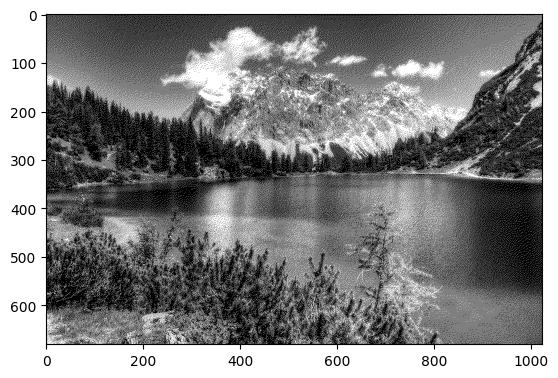

In [5]:
image = Image.open('data/image.jpg')
image = image.convert('1') # convert image to black and white

image = np.array(image)

# image = np.zeros((200, 200), dtype=np.float)
# for x in range(200):
#     for y in range(200):
#         d = ((x-100)**2+(y-100)**2)**0.5
#         image[x, y] = d % 8 < 4

plt.imshow(image, cmap='gray',vmin=0.0, vmax=1.0)
plt.show()

In [6]:
image = image.astype(float)

Next we test our implementation and apply a block filter with size 7

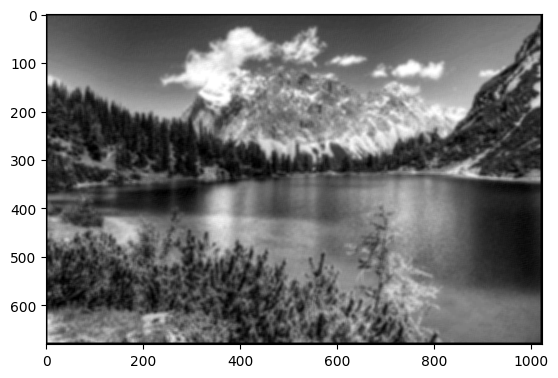

In [7]:
n = 7
H = block_filter(n)
J = apply_filter(image, H)

plt.imshow(J, cmap='gray')
plt.show()

## PyTorch Convolution <a class="anchor" id="pytorch" ></a>

In [8]:
from PIL import Image

img = Image.open('data/image.jpg')
# img.thumbnail((256,256), Image.ANTIALIAS) # Resize to half to reduce the size of this notebook. # ANTIALIAS is deprecated
img.thumbnail((256,256), Image.LANCZOS)

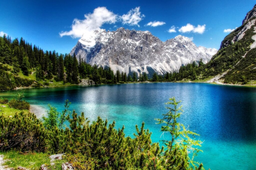

In [9]:
img

In [10]:
import torch, torchvision
from torchvision import transforms
from torch import nn

In [11]:
to_tensor = transforms.Compose([
   transforms.Grayscale(),  # Convert image to grayscale.
   transforms.ToTensor()    # Converts a PIL Image in the range [0, 255] to a torch.FloatTensor in the range [0.0, 1.0].
])

to_pil = transforms.Compose([
    transforms.ToPILImage()
])

In [12]:
input = to_tensor(img)
input.shape


torch.Size([1, 170, 256])

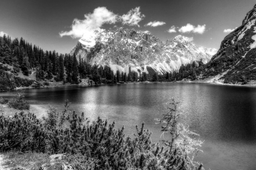

In [13]:
to_pil(input)

2D convolution over an input image:

+ `in_channels = 1`: an input is a grayscale image
+ `out_channels = 1`: an output is a grayscale image
+ `kernel_size = (3, 3)`: the kernel (filter) size is 3 x 3
+ `stride = 1`: the stride for the cross-correlation is 1
+ `padding = 1`: zero-paddings on both sides for 1 point for each dimension
+ `bias = False`: no bias parameter (for simplicity)

In [14]:
conv = nn.Conv2d(1, 1, (3, 3), stride=1, padding=1, bias=False)

In [15]:
# The code below does not work because the convolution layer requires the dimension for batch.
conv(input)

tensor([[[0.1043, 0.0884, 0.0873,  ..., 0.1338, 0.1337, 0.1448],
         [0.1530, 0.1256, 0.1248,  ..., 0.1872, 0.1872, 0.2846],
         [0.1548, 0.1275, 0.1259,  ..., 0.1876, 0.1856, 0.2854],
         ...,
         [0.4100, 0.3655, 0.2803,  ..., 0.1254, 0.1238, 0.1925],
         [0.4060, 0.3558, 0.3609,  ..., 0.1279, 0.1139, 0.1865],
         [0.2350, 0.0477, 0.0471,  ..., 0.0137, 0.0019, 0.1151]]],
       grad_fn=<SqueezeBackward1>)

We need to insert a dimension for a batch at dim=0.

In [16]:
input = input.unsqueeze(0)
input.shape

torch.Size([1, 1, 170, 256])

In [17]:
output = conv(input)
output.shape

torch.Size([1, 1, 170, 256])

Setting `padding=1` in the convolution layer, we obtain an image of the same size.

In [18]:
output.shape

torch.Size([1, 1, 170, 256])

We need to remove the first dimension before converting to a PIL object.

In [19]:
output.data.squeeze(dim=0).shape

torch.Size([1, 170, 256])

Display the output from the convolution layer by converting `output` to a PIL object.

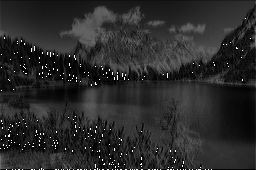

In [20]:
to_pil(output.data.squeeze(dim=0))

Clip every value in the output tensor within the range of [0, 1].

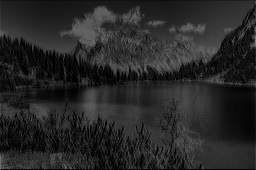

In [21]:
to_pil(torch.clamp(output, 0, 1).data.squeeze(dim=0))

In [22]:
def display(img1, img2):
    im1 = to_pil(torch.clamp(img1, 0, 1).data.squeeze(dim=0))
    im2 = to_pil(torch.clamp(img2, 0, 1).data.squeeze(dim=0))
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

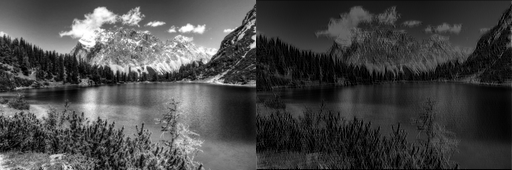

In [23]:
display(input, output)

### Identity

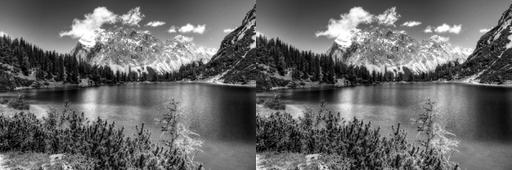

In [24]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1, 0.],
    [0., 0., 0.],
]]])

output = conv(input)
display(input, output)

### Brighten

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 1.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


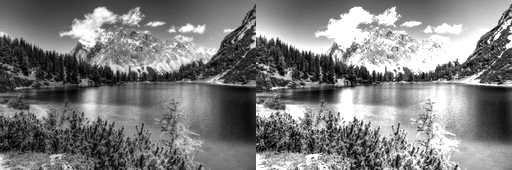

In [25]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Darken

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 0.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


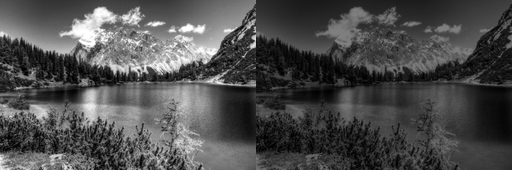

In [26]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 0.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Box blur

tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]])


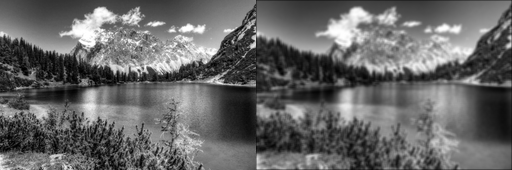

In [27]:
conv.weight.data = torch.ones((1, 1, 3,3), dtype=torch.float) / 9.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Gaussian blur

tensor([[[[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]]]])


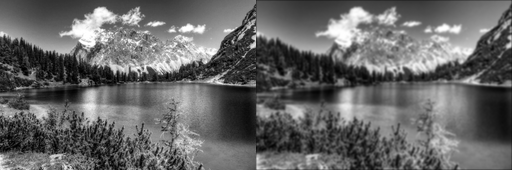

In [28]:
conv.weight.data = torch.tensor([[[
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.],
]]])/16.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Sharpen

tensor([[[[ 0., -1.,  0.],
          [-1.,  5., -1.],
          [ 0., -1.,  0.]]]])


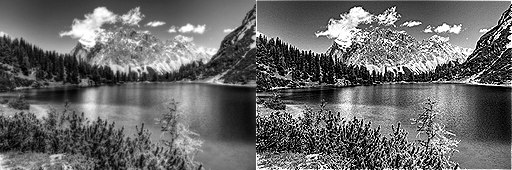

In [29]:
conv.weight.data = torch.tensor([[[
    [0., -1., 0.],
    [-1., 5., -1.],
    [0., -1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

tensor([[[[ 0., -2.,  0.],
          [-2., 10., -2.],
          [ 0., -2.,  0.]]]])


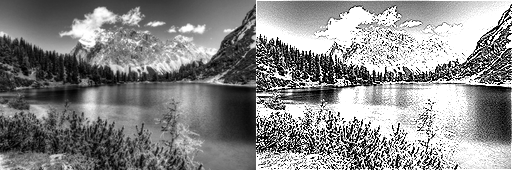

In [30]:
conv.weight.data = torch.tensor([[[
    [0., -2., 0.],
    [-2., 10., -2.],
    [0., -2., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Edge detection

tensor([[[[ 0.,  1.,  0.],
          [ 1., -4.,  1.],
          [ 0.,  1.,  0.]]]])


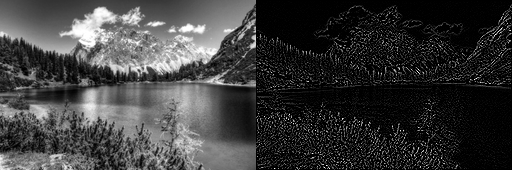

In [31]:
conv.weight.data = torch.tensor([[[
    [0., 1., 0.],
    [1., -4., 1.],
    [0., 1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

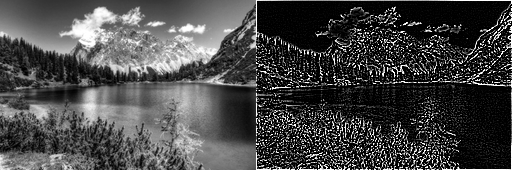

In [32]:
conv.weight.data = torch.tensor([[[
    [-1., -1., -1.],
    [-1., 8., -1.],
    [-1., -1., -1.],
]]])
output = conv(input)
display(input, output)

# > Solution

## 1 - Algorithmic Complexity Analysis of Edge Detection Operators

**Research Background**

Edge detection is a fundamental technique in computer vision that identifies points in a digital image where brightness changes sharply or discontinuities occur. These discontinuities typically correspond to object boundaries, surface orientation changes, or variations in material properties (Gonzalez & Woods, 2018). Edge detectors are essential preprocessing tools for image segmentation, object recognition, and feature extraction tasks. They work by computing local image gradients to highlight regions of rapid intensity change while suppressing areas of uniform intensity (Jain, 1989).

* **Prewitt Operator**

The Prewitt operator approximates image gradients using convolution with two 3×3 kernels that compute horizontal and vertical derivatives. The kernels assign equal weight to all pixels along each direction, providing a simple gradient estimation (Nixon & Aguado, 2020). After computing both directional gradients, the operator calculates the gradient magnitude using the Euclidean norm. 

Key characteristics include its simplicity of implementation, equal weighting scheme, and moderate noise sensitivity. The Prewitt operator produces relatively smooth edge maps but may miss subtle edges due to its uniform weighting approach (Parker, 2010). Its time complexity is **O(n·m)** where n and m represent image dimensions, requiring two convolution operations plus gradient magnitude computation.

* **Sobel Operator**

The Sobel operator functions similarly to Prewitt but uses weighted kernels that emphasize pixels closer to the center position. This weighting scheme, which assigns double weight to the central row or column, provides better noise suppression through implicit Gaussian smoothing (Gonzalez & Woods, 2018). The operator computes directional gradients and combines them to produce edge magnitude and direction information.

The Sobel operator demonstrates superior noise resistance compared to Prewitt, produces slightly smoother edge maps, and has become the most widely used first-order edge detector in practice (Jain, 1989). Despite the weighted kernels, it maintains the same **O(n·m)** computational complexity as Prewitt, requiring two convolutions and magnitude calculation.

* **Laplacian Operator**

Unlike gradient-based methods, the Laplacian operator is a second-order derivative technique that detects edges by identifying zero-crossings in the second derivative of image intensity. It uses a single kernel that approximates the Laplacian of a 2D Gaussian function, making it isotropic (rotation-invariant) and sensitive to intensity changes in all directions (Nixon & Aguado, 2020).

The Laplacian's main characteristics include its rotation invariance, high sensitivity to noise due to second-order differentiation, and ability to detect edges without directional bias. It produces thinner edges than gradient methods but requires careful noise handling, often through Gaussian pre-smoothing (Parker, 2010). With **O(n·m)** complexity, it requires only one convolution operation, making it computationally more efficient than gradient-based approaches.

* **Comparative Analysis**

All three operators share **O(n·m)** asymptotic complexity, but differ significantly in practical performance and characteristics. The **Laplacian is computationally most efficient**, performing approximately half the operations of Prewitt and Sobel by requiring only one convolution instead of two (Parker, 2010). 

In terms of edge quality, Sobel generally provides the best balance between noise suppression and edge detection accuracy due to its weighted approach. Prewitt offers simplicity with moderate performance, while Laplacian excels in detecting fine details but requires preprocessing for noisy images (Gonzalez & Woods, 2018). The choice among these operators depends on specific application requirements regarding computational resources, noise levels, and desired edge characteristics.

**References**

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4th ed.). Pearson.

- Jain, A. K. (1989). *Fundamentals of digital image processing*. Prentice Hall.

- Nixon, M. S., & Aguado, A. S. (2020). *Feature extraction and image processing for computer vision* (4th ed.). Academic Press.

- Parker, J. R. (2010). *Algorithms for image processing and computer vision* (2nd ed.). Wiley.

In [33]:
def convolve2d(image, kernel):
    """
    2D convolution without using OpenCV
    Args:
        image: 2D numpy array
        kernel: 2D numpy array (filter)
    Returns:
        Convolved image
    """
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    
    pad_h = ker_h // 2
    pad_w = ker_w // 2
    
    # Zero padding
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    
    # Output image
    output = np.zeros_like(image, dtype=np.float64)
    
    # Convolution operation
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.sum(region * kernel)
    
    return output

In [34]:
def prewitt(image):
    """
    Prewitt edge detector
    Args:
        image: 2D numpy array (grayscale image)
    Returns:
        Edge magnitude image
    """
    # Prewitt kernels
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]])
    
    kernel_y = np.array([[-1, -1, -1],
                         [0, 0, 0],
                         [1, 1, 1]])
    
    # Convolution
    grad_x = convolve2d(image, kernel_x)
    grad_y = convolve2d(image, kernel_y)
    
    # Magnitude
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    return magnitude

In [35]:
def sobel(image):
    """
    Sobel edge detector
    Args:
        image: 2D numpy array (grayscale image)
    Returns:
        Edge magnitude image
    """
    # Sobel kernels
    kernel_x = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])
    
    kernel_y = np.array([[-1, -2, -1],
                         [0, 0, 0],
                         [1, 2, 1]])
    
    # Convolution
    grad_x = convolve2d(image, kernel_x)
    grad_y = convolve2d(image, kernel_y)
    
    # Magnitude
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    return magnitude

In [36]:
def laplacian(image):
    """
    Laplacian edge detector
    Args:
        image: 2D numpy array (grayscale image)
    Returns:
        Edge detected image
    """
    # Laplacian kernel
    kernel = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]])
    
    # Convolution
    edges = convolve2d(image, kernel)
    
    return np.abs(edges)    

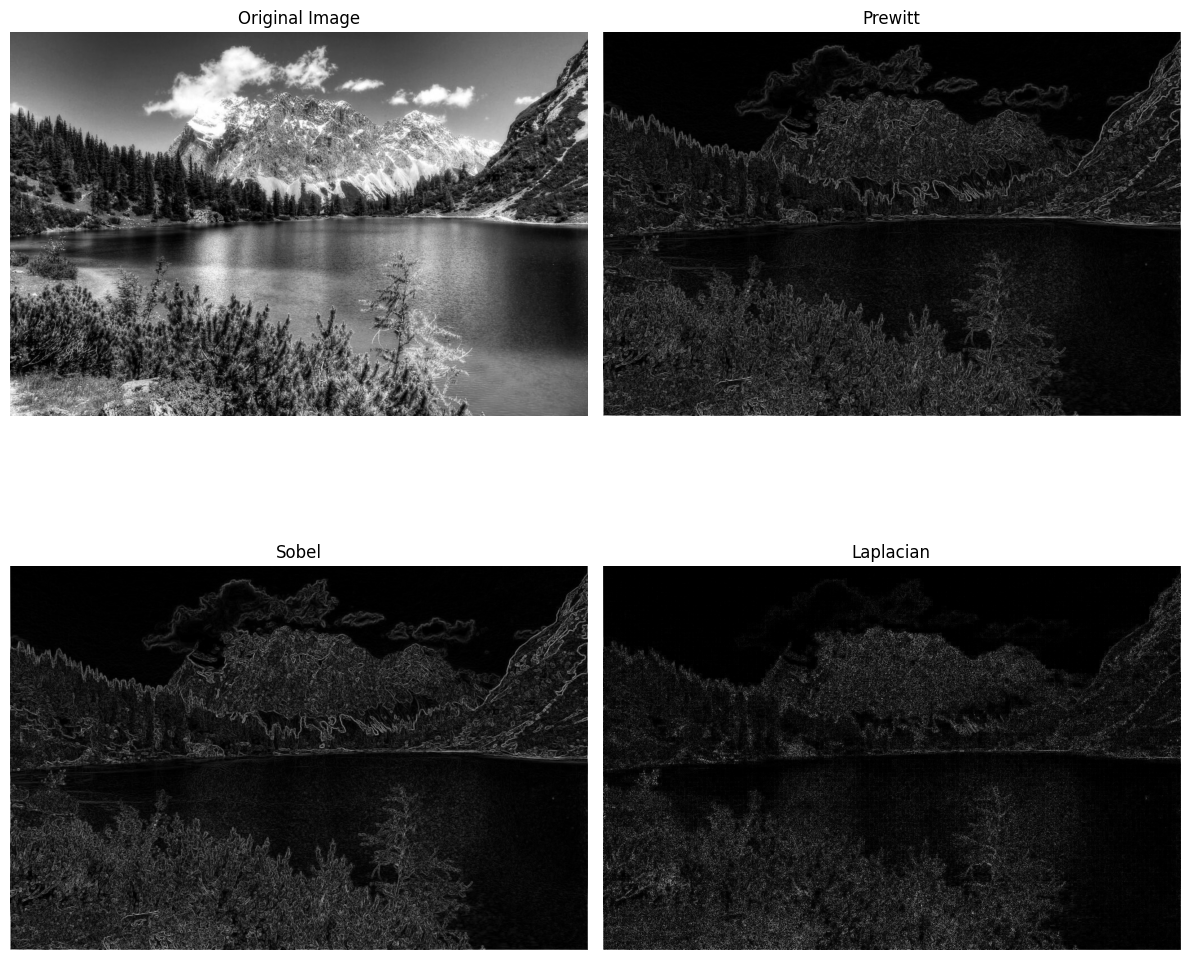

In [37]:
# Load image
img = Image.open('data/image.jpg').convert('L')  # Convert to grayscale
test_image = np.array(img, dtype=np.float64)

# Apply edge detectors
prewitt_edges = prewitt(test_image)
sobel_edges = sobel(test_image)
laplacian_edges = laplacian(test_image)

# Display results in 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(test_image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(prewitt_edges, cmap='gray')
axes[0, 1].set_title('Prewitt')
axes[0, 1].axis('off')

axes[1, 0].imshow(sobel_edges, cmap='gray')
axes[1, 0].set_title('Sobel')
axes[1, 0].axis('off')

axes[1, 1].imshow(laplacian_edges, cmap='gray')
axes[1, 1].set_title('Laplacian')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

The comparative results demonstrate that Sobel and Prewitt produce nearly identical edge maps, confirming their theoretical similarity in gradient-based detection. Both operators successfully identify prominent edges in the mountain ridges, treeline, and cloud formations with comparable intensity and continuity.

The Laplacian operator produces noticeably different results, detecting finer details and generating thinner, more defined edges. However, it also exhibits higher noise sensitivity, particularly visible in the sky region and water surface, where spurious edges appear due to subtle intensity variations. This validates the theoretical prediction that second-order derivatives amplify noise while detecting finer structural details (Gonzalez & Woods, 2018).

For this natural scene with moderate contrast and texture, Sobel provides the optimal balance between edge completeness and noise suppression. Laplacian would require Gaussian pre-filtering to achieve comparable robustness, while Prewitt offers minimal advantage over Sobel in this context.

## 2 - Edge-based Image Enhancement: Unsharp Masking Technique

**Research Background**

* **Image Enhancement Fundamentals**

Image enhancement is a fundamental operation in digital image processing that aims to improve visual quality by emphasizing specific features or correcting degradations. Enhancement techniques modify pixel intensities to increase contrast, sharpen edges, reduce noise, or highlight particular image characteristics (Gonzalez & Woods, 2018). Unlike image restoration, which attempts to recover degraded images using degradation models, enhancement is subjective and application-dependent, focusing on improving visual appearance for specific tasks or human perception (Jain, 1989).

Unsharp masking is a classical enhancement technique that sharpens images by emphasizing high-frequency components, particularly edges. The method derives its name from traditional photography, where a blurred (unsharp) positive image was subtracted from the original to create a mask highlighting edges (Russ, 2016). In digital implementation, the process involves three main steps: edge detection to create a mask, amplification of the mask using a scaling factor, and addition of the amplified mask to the original image (Polesel et al., 2000).

The mathematical formulation is expressed as: `I_enhanced = I_original + α × M`
where I represents the image, M is the edge mask, and α is the enhancement factor. This additive approach directly reinforces edge information while preserving overall image structure (Gonzalez & Woods, 2018).

The alpha parameter controls enhancement intensity and represents the amplification factor applied to detected edges. When α > 1, the edge mask is magnified before being added to the original image, producing sharper, more pronounced edges (Russ, 2016). The value of α determines the enhancement degree: small values (1.0 < α < 2.0) produce subtle sharpening suitable for general enhancement, moderate values (2.0 ≤ α < 4.0) create noticeable sharpening for feature emphasis, and large values (α ≥ 4.0) generate aggressive sharpening that may introduce artifacts or halos around edges (Polesel et al., 2000).

The selection of α depends on image content, noise levels, and application requirements. Images with low contrast benefit from higher α values, while noisy images require conservative values to avoid amplifying noise alongside edges (Nixon & Aguado, 2020).

* **Algorithm Characteristics and Considerations**

Edge-based enhancement offers several advantages, including selective sharpening that targets edge regions while preserving smooth areas, computational efficiency through simple arithmetic operations, and controllable enhancement via the α parameter (Gonzalez & Woods, 2018). However, the technique also presents challenges: it amplifies noise present in the image, particularly with high α values; it may create overshooting artifacts (halos) around strong edges; and it requires careful edge detector selection, as different operators produce varying enhancement results (Russ, 2016).

The computational complexity is dominated by the edge detection step, typically O(n·m) for gradient-based operators, with the enhancement operation itself being O(n·m) for pixel-wise addition. This makes the overall algorithm efficient for real-time applications (Polesel et al., 2000).

* **Practical Applications**

Edge-based enhancement is widely employed in medical imaging for emphasizing anatomical structures, satellite imagery for feature extraction, photography for artistic sharpening effects, and machine vision systems for preprocessing before feature detection (Nixon & Aguado, 2020). The technique's simplicity and effectiveness have made it a standard tool in image processing pipelines, often implemented in commercial software and imaging devices.

**References**

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4th ed.). Pearson.

- Jain, A. K. (1989). *Fundamentals of digital image processing*. Prentice Hall.

- Nixon, M. S., & Aguado, A. S. (2020). *Feature extraction and image processing for computer vision* (4th ed.). Academic Press.

- Polesel, A., Ramponi, G., & Mathews, V. J. (2000). *Image enhancement via adaptive unsharp masking*. IEEE Transactions on Image Processing, 9(3), 505-510. https://doi.org/10.1109/83.826787

- Russ, J. C. (2016). *The image processing handbook* (7th ed.). CRC Press.

In [38]:
def enhance_image(image, alpha=1.5):
    """
    Image enhancement using edge-based sharpening
    Args:
        image: 2D numpy array (grayscale image)
        alpha: Enhancement factor (alpha > 1)
    Returns:
        Enhanced image
    """
    # Extract edges (mask)
    edges = sobel(image)
    
    # Multiply mask by alpha factor
    enhanced_edges = edges * alpha
    
    # Add enhanced edges to original image
    enhanced = image + enhanced_edges
    
    # Clip values to valid range [0, 255]
    enhanced = np.clip(enhanced, 0, 255)
    
    return enhanced, edges

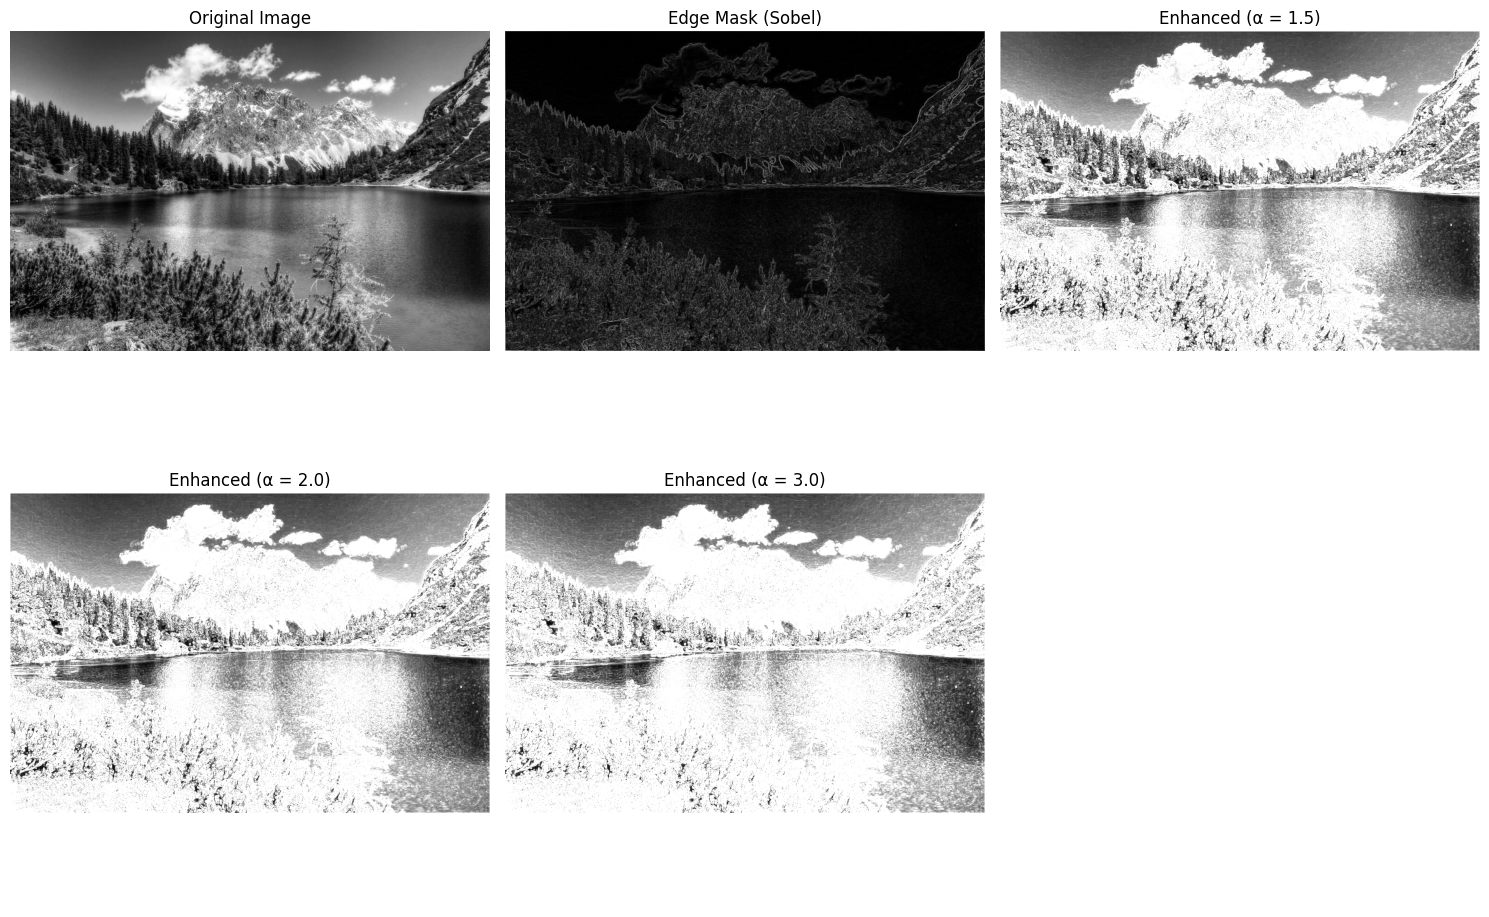

In [39]:
# Load image
img = Image.open('data/image.jpg').convert('L')
original = np.array(img, dtype=np.float64)

# Apply enhancement with different alpha values
enhanced_15, edges = enhance_image(original, alpha=1.5)
enhanced_20, _ = enhance_image(original, alpha=2.0)
enhanced_30, _ = enhance_image(original, alpha=3.0)

# Display results in 2x3 subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(original, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges, cmap='gray')
axes[0, 1].set_title('Edge Mask (Sobel)')
axes[0, 1].axis('off')

axes[0, 2].imshow(enhanced_15, cmap='gray')
axes[0, 2].set_title('Enhanced (α = 1.5)')
axes[0, 2].axis('off')

axes[1, 0].imshow(enhanced_20, cmap='gray')
axes[1, 0].set_title('Enhanced (α = 2.0)')
axes[1, 0].axis('off')

axes[1, 1].imshow(enhanced_30, cmap='gray')
axes[1, 1].set_title('Enhanced (α = 3.0)')
axes[1, 1].axis('off')

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

The results demonstrate the progressive intensification of edge enhancement as the alpha factor increases. At α = 1.5, the image exhibits subtle sharpening with enhanced definition of mountain contours, tree boundaries, and cloud edges while maintaining natural appearance. The water surface remains relatively smooth, indicating selective enhancement of high-frequency components.

At α = 2.0, sharpening becomes more pronounced, with clearly accentuated edges throughout the scene. Textural details in vegetation and rock formations become more visible, though some noise amplification begins to appear in uniform regions like the sky and water.

With α = 3.0, the enhancement reaches aggressive levels, producing a highly stylized appearance with pronounced edges and visible artifacts. The technique now amplifies noise significantly, particularly evident in the sky gradients and water reflections, creating a grainy texture. This confirms the theoretical prediction that excessive alpha values introduce overshooting artifacts and amplify unwanted noise (Polesel et al., 2000).

For this natural landscape, α values between 1.5 and 2.0 provide optimal enhancement, achieving improved edge definition without severe artifacts. Values beyond 2.5 compromise image quality by over-emphasizing noise, demonstrating the critical importance of alpha parameter selection based on image content and noise characteristics.

## 3 - Image Enhancement in Medical PET Imaging

**Research Background**

Image enhancement is critical in medical imaging for improving visual quality and diagnostic accuracy. In PET imaging, noise and artifacts inherent to the acquisition process can significantly degrade image quality, limiting the ability to detect subtle pathological changes. Enhancement techniques address these limitations by reducing noise, improving contrast, and sharpening anatomical details, thereby enabling clinicians to make more confident diagnostic decisions (Gonzalez & Woods, 2018).

* **PET Imaging Challenges**

PET is a nuclear medicine technique that detects pairs of gamma rays emitted by positron-emitting radiotracers, providing functional information about metabolic processes in the body. It is widely used in oncology for tumor detection and staging, in neurology for diagnosing dementia, and in cardiology for assessing heart function. However, PET images suffer from low signal-to-noise ratio, limited spatial resolution, and statistical noise due to the stochastic nature of radioactive decay and photon detection. These factors compromise image quality and can obscure critical diagnostic information.

* **Enhancement Techniques for PET Images**

    * *Noise Reduction Filters*
    
    Gaussian filtering is commonly used in PET imaging to reduce background noise and improve signal-to-noise ratio with better contrast. The Gaussian lowpass filter smooths the image by averaging neighboring pixels with weights determined by a Gaussian function, effectively suppressing high-frequency noise (Gonzalez & Woods, 2018). However, Gaussian filtering also generates image distortion depending on filter size, which affects quantitative analysis.
    
    Median filtering is effective for removing impulse noise while preserving edges better than linear filters. In medical imaging, median filters are particularly valuable for suppressing salt-and-pepper noise without excessive blurring, making them suitable for preserving anatomical boundaries in PET scans (Nixon & Aguado, 2020).

    * *Contrast Enhancement*
    
    Histogram equalization redistributes pixel intensities to utilize the full dynamic range, thereby improving contrast in low-contrast PET images. This technique is particularly beneficial for FDG-PET imaging, where metabolic activity differences between diseased and healthy tissues must be clearly visualized. Enhanced contrast enables better differentiation of tumor boundaries and improved detection of metastatic lesions (Gonzalez & Woods, 2018).

* **Clinical Impact and Applications**

AI-based image enhancement methods have demonstrated significant potential for improving PET image analysis, with most approaches outperforming conventional methods by a striking margin. Recent studies show that digital PET with AI-based enhancement can reduce acquisition time to as fast as CT scans while maintaining diagnostic quality, enabling faster patient throughput and reduced radiation exposure.

Image filtering improves diagnostic accuracy by reducing noise and artifacts, enabling clinicians to make more confident diagnoses and treatment decisions. Specifically, enhanced PET images facilitate better tumor detection and improve segmentation accuracy by reducing noise and preserving edges, helping clinicians identify tumor boundaries more accurately.

* **Limitations and Future Directions**

A key challenge in AI-based PET enhancement stems from poor generalizability of trained models, as data size and variability often lead to performance drops when applied to different scanners, protocols, or tracers. Multi-site studies face inter-site differences in scanner models and image acquisition protocols, leading to significant variability in image characteristics and motivating data harmonization techniques.

Future research directions include development of hybrid filtering approaches, transfer learning for improved filter performance, and integration of image filtering with other tasks such as segmentation and registration. These advances promise to further enhance the clinical utility of PET imaging in disease diagnosis and treatment monitoring.

**References**

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4th ed.). Pearson.

- Nixon, M. S., & Aguado, A. S. (2020). *Feature extraction and image processing for computer vision* (4th ed.). Academic Press.

In [40]:
def gaussian_kernel(size, sigma):
    """
    Create Gaussian kernel
    Args:
        size: kernel size (must be odd)
        sigma: standard deviation
    Returns:
        Normalized Gaussian kernel
    """
    kernel = np.zeros((size, size))
    center = size // 2
    
    for i in range(size):
        for j in range(size):
            x, y = i - center, j - center
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    return kernel / np.sum(kernel)

In [41]:
def gaussian_filter(image, kernel_size=19, sigma=3):
    """
    Apply Gaussian lowpass filter
    Args:
        image: Input image
        kernel_size: Size of Gaussian kernel
        sigma: Standard deviation
    Returns:
        Filtered image
    """
    kernel = gaussian_kernel(kernel_size, sigma)
    return convolve2d(image, kernel)

In [42]:
def median_filter(image, kernel_size=7):
    """
    Apply median filter
    Args:
        image: Input image
        kernel_size: Size of median filter window
    Returns:
        Filtered image
    """
    img_h, img_w = image.shape
    pad = kernel_size // 2
    
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')
    output = np.zeros_like(image, dtype=np.float64)
    
    for i in range(img_h):
        for j in range(img_w):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            output[i, j] = np.median(window)
    
    return output

In [43]:
def histogram_equalization(image):
    """
    Apply histogram equalization
    Args:
        image: Input image (0-255 range)
    Returns:
        Equalized image
    """
    # Calculate histogram
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    
    # Calculate cumulative distribution function (CDF)
    cdf = hist.cumsum()
    cdf_normalized = cdf * 255 / cdf[-1]
    
    # Use linear interpolation to get new pixel values
    image_equalized = np.interp(image.flatten(), bins[:-1], cdf_normalized)
    
    return image_equalized.reshape(image.shape)

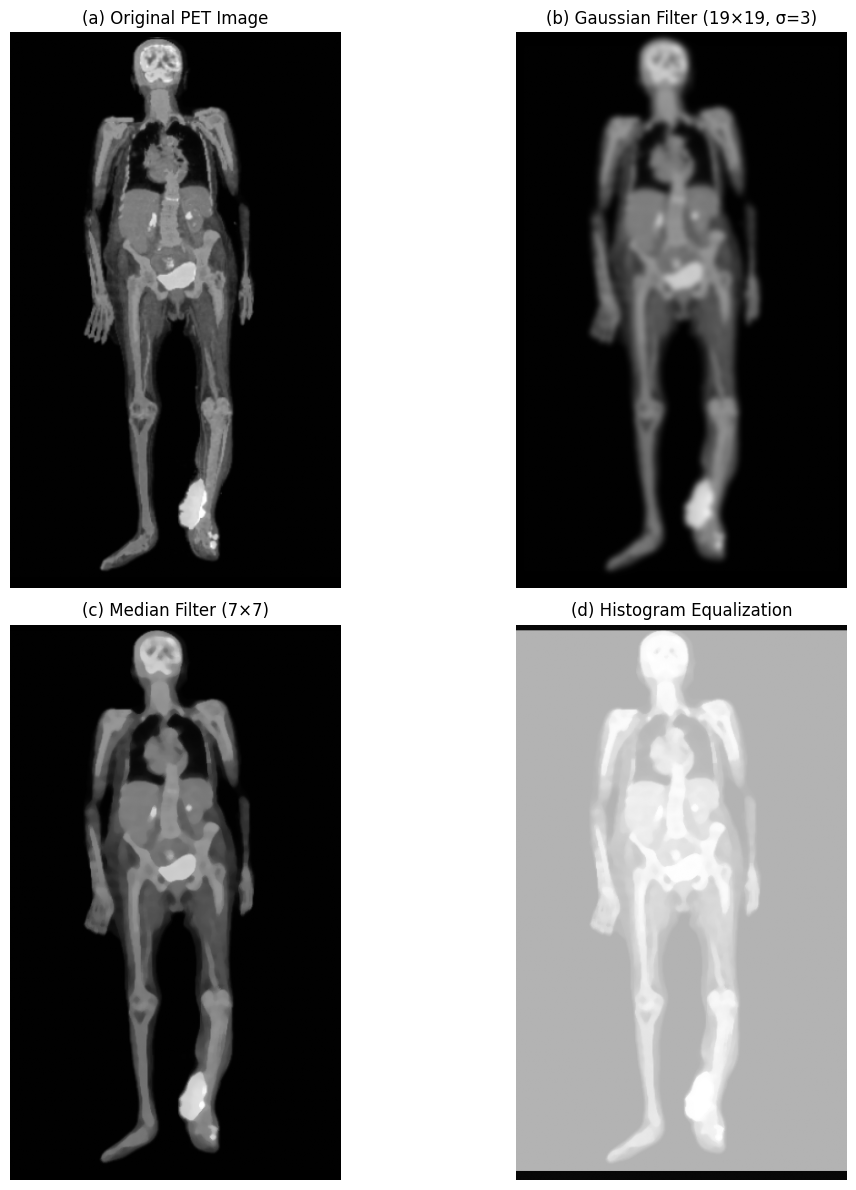

In [44]:
# Load PET scan image
img = Image.open('data/pet_scan.png').convert('L')
original = np.array(img, dtype=np.float64)

# Step 1: Noise reduction using Gaussian filter (similar to Fig 3.43b)
gaussian_filtered = gaussian_filter(original, kernel_size=19, sigma=3)

# Step 2: Noise reduction using Median filter (similar to Fig 3.43c)
median_filtered = median_filter(original, kernel_size=7)

# Step 3: Histogram equalization for contrast enhancement
equalized = histogram_equalization(median_filtered)

# Display results in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('(a) Original PET Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(gaussian_filtered, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('(b) Gaussian Filter (19×19, σ=3)')
axes[0, 1].axis('off')

axes[1, 0].imshow(median_filtered, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('(c) Median Filter (7×7)')
axes[1, 0].axis('off')

axes[1, 1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('(d) Histogram Equalization')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

The enhancement pipeline demonstrates progressive improvement in PET image quality through strategic noise reduction and contrast optimization. The Gaussian filter (b) effectively reduces statistical noise inherent to PET acquisition by smoothing high-frequency components, improving overall signal-to-noise ratio. However, this smoothing introduces slight blurring of anatomical boundaries, a characteristic trade-off of linear filters.

The median filter (c) achieves superior noise suppression while preserving edge definition, particularly visible in organ boundaries and skeletal structures. This edge-preserving property is crucial for accurate delineation of metabolic activity regions, making median filtering preferable for maintaining diagnostic precision in PET images where spatial localization is critical.

Histogram equalization (d) dramatically enhances contrast by redistributing pixel intensities across the full dynamic range. This transformation amplifies the visibility of subtle metabolic differences between tissues, clearly highlighting high-uptake regions (brain, liver, bladder) against background activity. The enhanced contrast facilitates detection of pathological uptake patterns and improves tumor-to-background ratios, essential for oncological diagnosis.

These enhancement techniques address PET imaging's inherent challenges—low spatial resolution and statistical noise from radioactive decay. The combination of noise reduction followed by contrast enhancement enables clinicians to visualize metabolic abnormalities more confidently, improving diagnostic accuracy for cancer detection, staging, and treatment monitoring (Gonzalez & Woods, 2018). The median filter's edge preservation and histogram equalization's contrast improvement prove particularly valuable for identifying subtle lesions and precise tumor boundary delineation in clinical practice.